# How can a bank minimise total financial loss by identifying early-warning behavioral patterns for both credit defaults and fraudulent transactions 

## Goal

To identify and interpret the data from the credit card dataset in order to find trends in terms of three main factors which are: Debt to income ratio, Defaulting and Fraud Transactions. 

## Business Problem

The company has had issues with choosing the correct customers to take on for their credit card scheme. This is due to a variety of factors including Their debt-to-income ratio, fraud transaction history as well as whether their account has defaulted in the past.  

Our team of business intelligence consultants have found a dataset that will allow us to take an in depth investigate the current situation at the company and then be able to spot trends or potential opportunities that can be capitalised on. 

## Justification

We have chosen this problem as it is a complex analysis to undertake. There are a lot of variables that can be used which show whether a customer is reliable and a good fit for the credit card or not. However, at the same time there is an uncertainty on if all the variables are relevant to make an informed decision. For example, would certain criteria such as marital status or education level be reasonable to base a decision off certain trends? 

In terms of dataset selection, we chose this dataset as it aligns with the aims of the project. Over 20 different variables are available within the dataset which gives us a wide range to choose from in terms of correlation to credit score or income. Therefore, we can cross examine the results with others to create a wider picture of the customer habits and be able to make an in-depth analysis with pertinent information for the case study. 

The dataset is appropriate as it also uses different data types which allow for our team of Business Intelligence consultants to display the information using charts, graphs or tables which suit the information. Furthermore, in comparison to other credit card datasets the columns are visible and not anonymised due to privacy concerns.  

Some examples of the different data types that we use are binary data – Gender, Discrete data – Total Transactions and Continuous data – Annual income.  

## 2 Data Analysis

### 2.1

To understand the data’s structure and limitations we must first explore, clean and prepare it for analysis. As this is a critical stage of the project it is important that all 10,0000 rows and 24 columns make logical sense and are ready for visualisation. 

Initially, we started with summarising the data using the ‘df.head’ method to analyse the first 5 rows of data and familiarise ourselves with the information. Thereafter, we use the method ‘df.info’ to list all the data types. In this stage it is important to maintain accuracy. While scanning our dataset we spotted column #15 Defaulted was stored as an integer when the results values only show 0 or 1 which is Boolean data. As a result, we used data transformation to correct the issue within the data set which will be helpful in the latter stages of our analysis as it will guide what graphs we choose to use. 

### 2.2

We begin by loading the dataset and performing an initial exploration to understand its structure, content, and quality.

As data analysis consultants' we must ensure that we understand our dataset so we can find any of the current limitations and work towards a cleansed dataset.

Loading the Data: We load the data from the CSV file into a pandas DataFrame, which is a powerful data structure for handling tabular data in Python.

Inspecting the Data: We will examine the first few rows to get a feel for the data, check the data types of each column to ensure they are appropriate, and generate summary statistics to understand the distribution of numerical data.

Checking Data Quality: We will check for missing values and duplicate records, which are common issues that can affect the quality of our analysis and modelling.

The following code cells perform these initial exploratory steps.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# Display the first few rows of the dataframe
print("First 5 rows of the credit card dataset:")
print(df.head())

First 5 rows of the credit card dataset:
  Customer_ID  Age  Gender Marital_Status Education_Level Employment_Status  \
0  CUST_00001   59    Male        Married             PhD        Unemployed   
1  CUST_00002   49    Male       Divorced     High School        Unemployed   
2  CUST_00003   35    Male        Married        Bachelor          Employed   
3  CUST_00004   63    Male         Single        Bachelor          Employed   
4  CUST_00005   28  Female        Married          Master          Employed   

   Annual_Income  Credit_Score  Number_of_Credit_Lines  \
0          41442           642                       4   
1          85992           665                       7   
2          58420           683                       8   
3          59733           674                       7   
4          69487           733                       5   

   Credit_Utilization_Ratio  ...  Total_Spend_Last_Year  Defaulted     CLV  \
0                      0.44  ...                  13997  

The .info() method provides a concise summary of the DataFrame, including the number of non-null entries in each column and their data types. This is very useful for identifying columns with missing data.

In [4]:
# Compare the first 10 columns with the data type to see if it is accurate
# Object = string, Police_force + Collision_severity should be a category data type
# Get information about the columns and their data types
print("To start cleaning the data we check to ensure that all of the variables are in the correct data type.")
print("")
print(df.info())

To start cleaning the data we check to ensure that all of the variables are in the correct data type.

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_ID                   10000 non-null  str    
 1   Age                           10000 non-null  int64  
 2   Gender                        10000 non-null  str    
 3   Marital_Status                10000 non-null  str    
 4   Education_Level               10000 non-null  str    
 5   Employment_Status             10000 non-null  str    
 6   Annual_Income                 10000 non-null  int64  
 7   Credit_Score                  10000 non-null  int64  
 8   Number_of_Credit_Lines        10000 non-null  int64  
 9   Credit_Utilization_Ratio      10000 non-null  float64
 10  Debt_To_Income_Ratio          10000 non-null  float64
 11  Number_of_Late_Payments     

The .info() method generates descriptive statistics that summarise each column into its data type and whether it contains null values.

In the table able we critically analysed the data points in the context of a credit card company and assessed that the values all belonged to the correct data type.

In [5]:
# Get summary statistics of the numerical columns
print("Summary Statistics for Columns:")
print("")
print(df.describe())

Summary Statistics for Columns:

                Age  Annual_Income  Credit_Score  Number_of_Credit_Lines  \
count  10000.000000   10000.000000  10000.000000            10000.000000   
mean      45.151500   60266.917400    648.739800                4.997100   
std       14.083223   15109.825468     50.082106                2.600494   
min       21.000000     576.000000    469.000000                1.000000   
25%       33.000000   50161.750000    615.000000                3.000000   
50%       45.000000   60167.500000    649.000000                5.000000   
75%       57.000000   70355.250000    683.000000                7.000000   
max       69.000000  112128.000000    832.000000                9.000000   

       Credit_Utilization_Ratio  Debt_To_Income_Ratio  \
count              10000.000000          10000.000000   
mean                   0.499742              0.496404   
std                    0.291170              0.288152   
min                    0.000000              0.000000 

In terms of handling missing values, the team carefully selected a dataset which had minimal inconsistencies in terms of missing values or incorrect data. Therefore, we can have confidence in our data structure for use in analysis.  

However, the limited preprocessing required suggests that the dataset has already gone through prior cleaning. While this does improve the usability it may also be obscuring real world data quality issues that the bank would face in real life due to factors such as human error or digital mistakes. 

Although, as stated previously, there were no additional transformations the existing data does have certain qualities such as class imbalance for defaulting that have a wide range of variables that can impact the outcome. 

In [6]:
# Check for missing values
# Local authority highway current has missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Customer_ID                     0
Age                             0
Gender                          0
Marital_Status                  0
Education_Level                 0
Employment_Status               0
Annual_Income                   0
Credit_Score                    0
Number_of_Credit_Lines          0
Credit_Utilization_Ratio        0
Debt_To_Income_Ratio            0
Number_of_Late_Payments         0
Tenure_in_Years                 0
Total_Transactions_Last_Year    0
Total_Spend_Last_Year           0
Defaulted                       0
CLV                             0
Total_Transactions              0
Avg_Transaction_Amount          0
Max_Transaction_Amount          0
Min_Transaction_Amount          0
Fraud_Transactions              0
Unique_Merchant_Categories      0
Unique_Transaction_Cities       0
dtype: int64


## 3 Data Visualisation

Data Mining and Business Insights 

The overall default rate across the dataset is 34.5% and 28.3% of customers have at least one fraudulent transaction recorded. The analysis below explores the behavioural patterns driving these figures across two streams - default and fraud - before combining both dimensions through K-Means clustering to produce actionable customer segments. 

### Default Related Graphs

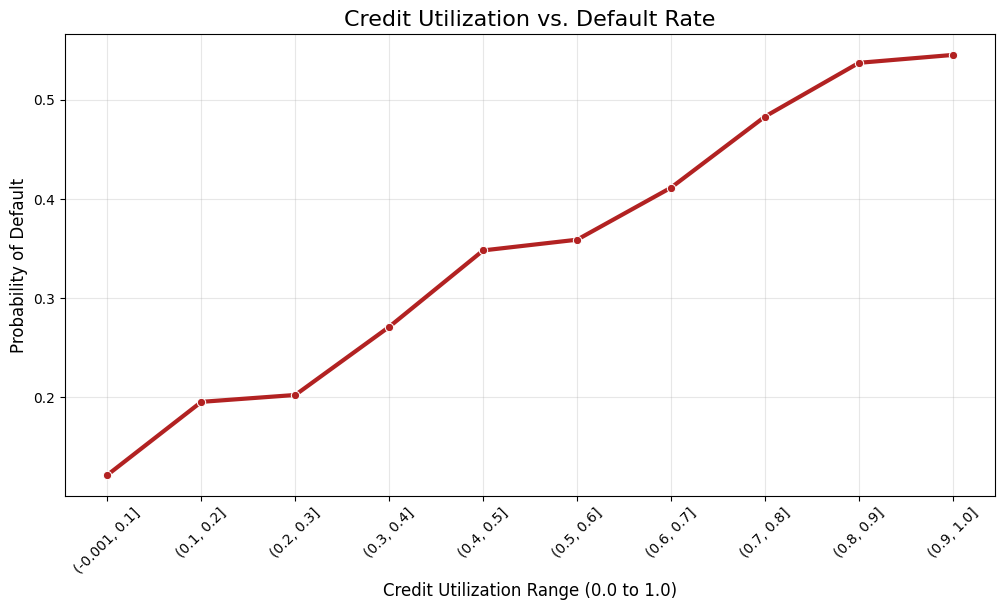

In [8]:
# 1. Create Utilization Bins (Grouping makes the correlation much clearer)
df['util_bins'] = pd.cut(df['Credit_Utilization_Ratio'], bins=10)

# 2. Calculate the mean default rate per bin
util_trend = df.groupby('util_bins', observed=True)['Defaulted'].mean().reset_index()

# 3. Convert the bins to strings for the x-axis
util_trend['util_bins'] = util_trend['util_bins'].astype(str)

# 4. Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=util_trend, x='util_bins', y='Defaulted', marker='o', color='firebrick', linewidth=3)

plt.title('Credit Utilization vs. Default Rate', fontsize=16)
plt.xlabel('Credit Utilization Range (0.0 to 1.0)', fontsize=12)
plt.ylabel('Probability of Default', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

Credit Utilization vs. Default Rate 

A line plot was chosen here because credit utilisation is a continuous variable and a line plot most clearly communicates directional trend across ordered bands, making the escalating risk immediately readable to a non-technical stakeholder. 

The plot groups customers into ten utilisation bands and shows average default probability within each. 

The relationship is near-linear and consistent: customers below 10% utilisation default at just 12.1%, rising to 54.5% for those above 90% - more than four times higher. Risk begins escalating meaningfully beyond the 0.4 mark (34.8%), suggesting 40% utilisation as a practical early-warning threshold. This confirms credit utilisation as the single strongest individual predictor of default in this dataset. 

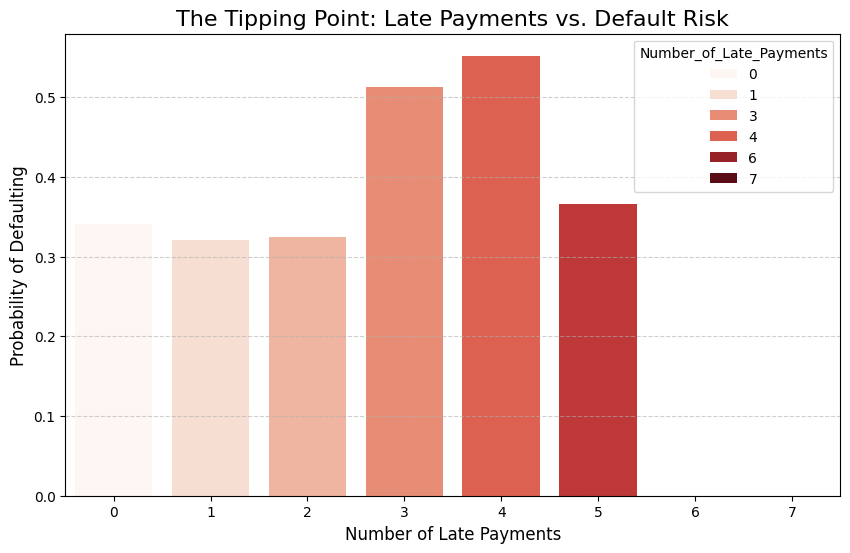

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate average default rate per number of late payments
late_trend = df.groupby('Number_of_Late_Payments')['Defaulted'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(
    data=late_trend, 
    x='Number_of_Late_Payments', 
    y='Defaulted', 
    palette='Reds', # Red emphasizes "Danger/Risk" 
    hue='Number_of_Late_Payments'
)

plt.title('The Tipping Point: Late Payments vs. Default Risk', fontsize=16)
plt.xlabel('Number of Late Payments', fontsize=12)
plt.ylabel('Probability of Defaulting', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Late Payments vs. Default Risk 

A bar chart was selected for this graph as the number of late payments is a discrete, countable variable where each value represents a distinct category. A bar chart communicates the magnitude of each group more clearly than a line, and the colour gradient reinforces the risk escalation visually. 

The data reveals a clear tipping point: customers with 0–2 late payments carry broadly similar default rates of 32–34%, but at 3 late payments the rate jumps sharply to 51.3%, peaking at 55.2% at 4 late payments. 

The third late payment is therefore the critical behavioural threshold - the point at which a customer transitions from occasionally struggling to structurally at risk. The bank should implement an automatic account review trigger at this point. 

### Fraud Related Graphs

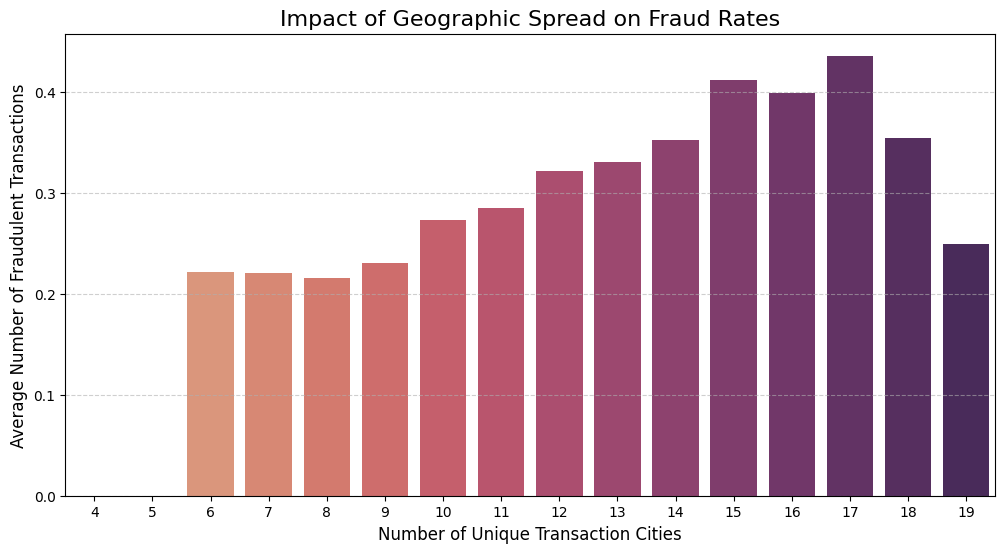

In [6]:
# 1. Group by the number of unique cities and calculate the average fraud rate
city_fraud_trend = df.groupby('Unique_Transaction_Cities')['Fraud_Transactions'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(12, 6))

# A barplot with a color gradient shows the escalating risk perfectly
sns.barplot(
    data=city_fraud_trend, 
    x='Unique_Transaction_Cities', 
    y='Fraud_Transactions', 
    palette='flare',      # 'flare' or 'Reds' works great for fraud/danger
    hue='Unique_Transaction_Cities',
    legend=False
)

plt.title('Impact of Geographic Spread on Fraud Rates', fontsize=16)
plt.xlabel('Number of Unique Transaction Cities', fontsize=12)
plt.ylabel('Average Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Geographic Spread vs. Fraud Rate 

A bar chart with a colour gradient (cool-to-warm) was chosen to communicate both the magnitude and direction of fraud risk escalation across discrete city count values. Customers transacting in only 4–5 unique cities show zero average fraud, while those active across 17 cities average 0.44 fraudulent transactions - over four times the low-spread group. 

This pattern reflects how fraud typically manifests: stolen credentials are used quickly across multiple locations before the victim notices, producing an abnormal geographic footprint. 

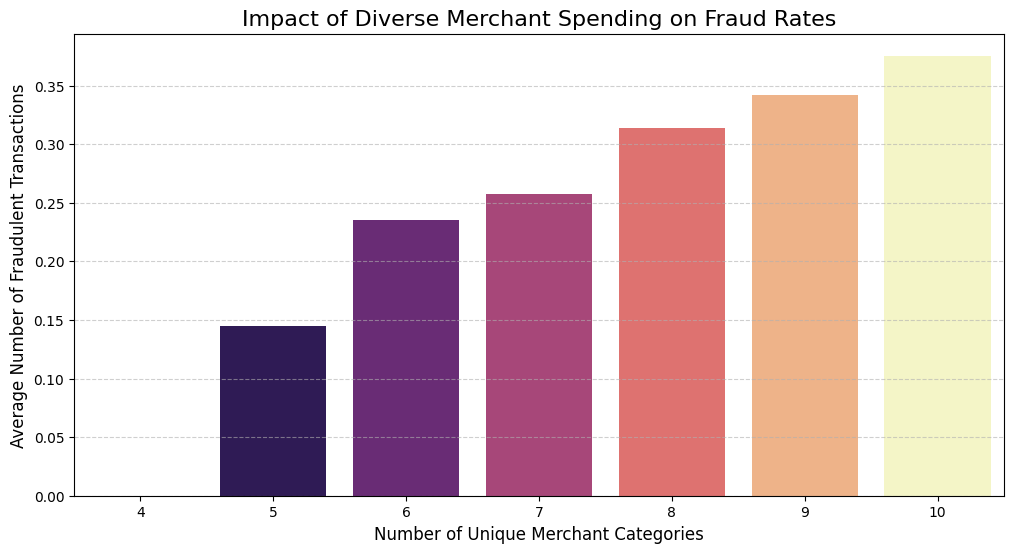

In [7]:
# 1. Group by the number of unique merchant categories and calculate the average fraud rate
category_fraud_trend = df.groupby('Unique_Merchant_Categories')['Fraud_Transactions'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(12, 6))

# A barplot with a color gradient shows the escalating risk
ax = sns.barplot(
    data=category_fraud_trend, 
    x='Unique_Merchant_Categories', 
    y='Fraud_Transactions', 
    palette='magma',      # 'magma' gives a great dark-to-light progression
    hue='Unique_Merchant_Categories'
)

# Clean up the legend (if one accidentally appears)
if ax.get_legend():
    ax.get_legend().remove()

plt.title('Impact of Diverse Merchant Spending on Fraud Rates', fontsize=16)
plt.xlabel('Number of Unique Merchant Categories', fontsize=12)
plt.ylabel('Average Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Merchant Category Diversity vs. Fraud Rate 

The same bar chart format was applied here for consistency and comparability with the geographic spread graph, allowing a stakeholder to immediately recognise the same risk-escalation pattern across a different variable. 

Customers spending across all 10 merchant categories average 0.375 fraud transactions compared to zero for those in only 4 categories. Fraudsters tend to make exploratory purchases across diverse categories to test whether a card is active. 

Combined with geographic spread, this forms a compound fraud signal more predictive than either variable alone. 

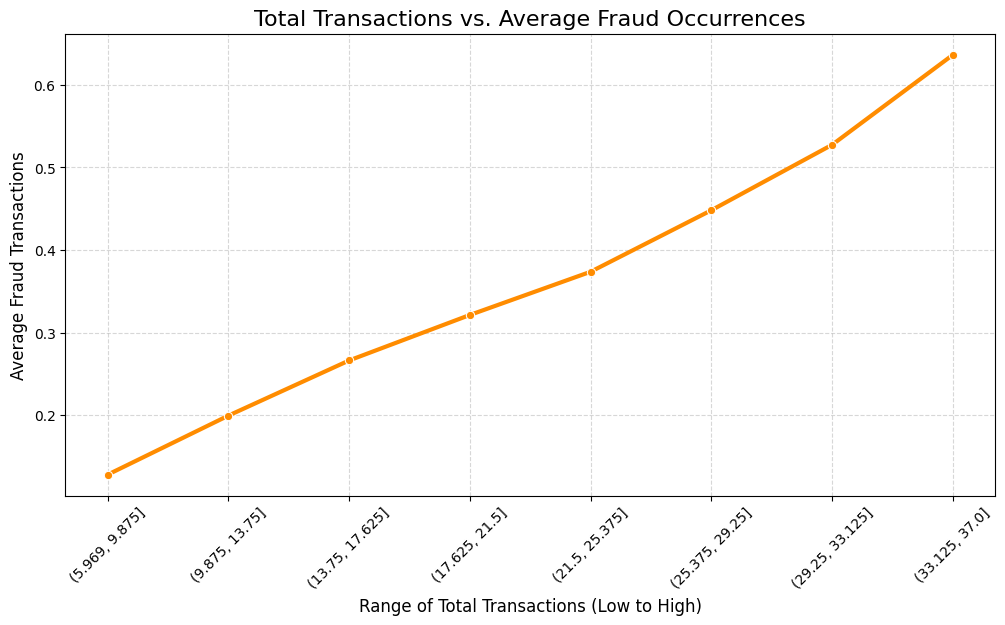

In [9]:
# 1. Group total transactions into 8 clean bins/ranges
df['Total_Transactions_Bins'] = pd.cut(df['Total_Transactions'], bins=8)

# 2. Calculate average fraud occurrences for each bin
fraud_trend = df.groupby('Total_Transactions_Bins', observed=True)['Fraud_Transactions'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=fraud_trend, 
    x=fraud_trend['Total_Transactions_Bins'].astype(str), 
    y='Fraud_Transactions', 
    marker='o', 
    color='darkorange', 
    linewidth=3
)

plt.title('Total Transactions vs. Average Fraud Occurrences', fontsize=16)
plt.xlabel('Range of Total Transactions (Low to High)', fontsize=12)
plt.ylabel('Average Fraud Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Total Transactions vs. Fraud Occurrences 

A line plot was used here rather than a bar chart because total transactions are binned into ranges, and the line format most effectively communicates the continuous upward trajectory across those ranges. 

Average fraud transactions rise from 0.13 in the lowest volume band (6–10 transactions) to 0.64 in the highest (33–37 transactions). Crucially, the rate of fraud as a proportion of total transactions also increases, meaning high-volume customers are not simply exposed to more opportunities - they represent a qualitatively higher-risk profile and warrant more intensive fraud screening. 

## Clustering and Classification Modelling

Clustering Models 

K-Means was selected as the clustering algorithm for all three models due to its interpretability, computational efficiency on a 10,000-row dataset, and its ability to produce clearly defined centroids that can be directly translated into customer risk profiles. All features were standardised using StandardScaler prior to fitting, as K-Means relies on Euclidean distance and would otherwise be biased toward variables with larger numeric ranges. Three clusters (k=3) were chosen across all models to produce a simple low/medium/high segmentation that is immediately meaningful to a business audience without over-complicating the output. 

### Cluster Models

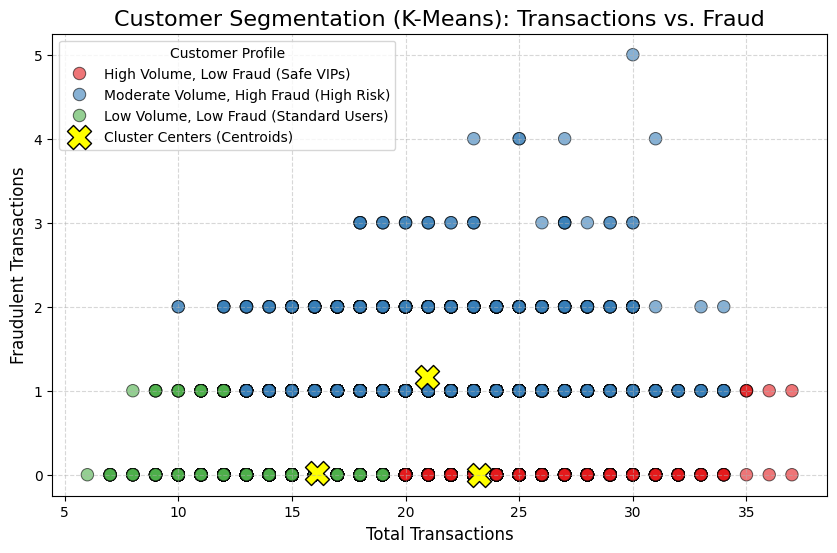

--- Average Values per Customer Segment ---
                                         Total_Transactions  \
Customer_Segment                                              
High Volume, Low Fraud (Safe VIPs)                23.229658   
Low Volume, Low Fraud (Standard Users)            16.089909   
Moderate Volume, High Fraud (High Risk)           20.938088   

                                         Fraud_Transactions  
Customer_Segment                                             
High Volume, Low Fraud (Safe VIPs)                 0.001389  
Low Volume, Low Fraud (Standard Users)             0.016772  
Moderate Volume, High Fraud (High Risk)            1.167994  


In [12]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Select the features for clustering
features = ['Total_Transactions', 'Fraud_Transactions']
X = df[features]

# 4. Scale the data
# K-Means calculates physical distance between points. We MUST scale the data 
# so 'Total_Transactions' (which can be 30+) doesn't mathematically overpower 
# 'Fraud_Transactions' (which is usually 0-5).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Build the K-Means Model
# We set n_clusters=3 to create 3 distinct "Customer Segments"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Map the clusters to meaningful business names
segment_names = {
    0: 'High Volume, Low Fraud (Safe VIPs)', 
    1: 'Moderate Volume, High Fraud (High Risk)', 
    2: 'Low Volume, Low Fraud (Standard Users)'
}
df['Customer_Segment'] = df['Cluster'].map(segment_names)

# 6. VISUALIZATION: The Scatter Plot
plt.figure(figsize=(10, 6))

# Plot the individual customers
sns.scatterplot(
    data=df,
    x='Total_Transactions',
    y='Fraud_Transactions',
    hue='Customer_Segment',
    palette='Set1',
    s=80,      # Size of the dots
    alpha=0.6, # Transparency to see overlapping points
    edgecolor='black'
)

# 7. Add the Cluster Centers (The "Centroids")
# We have to reverse the scaling so the "X" marks show up on the correct normal numbers
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_unscaled[:, 0], 
    centers_unscaled[:, 1], 
    c='yellow', 
    s=300, 
    marker='X', 
    edgecolor='black', 
    label='Cluster Centers (Centroids)'
)

plt.title('Customer Segmentation (K-Means): Transactions vs. Fraud', fontsize=16)
plt.xlabel('Total Transactions', fontsize=12)
plt.ylabel('Fraudulent Transactions', fontsize=12)
plt.legend(title='Customer Profile')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 8. Print the averages for each cluster for your report!
print("--- Average Values per Customer Segment ---")
print(df.groupby('Customer_Segment')[features].mean())

Transactions vs. Fraud 

Three segments emerge: High Volume Low Fraud (avg 23.2 transactions, 0.001 fraud), Moderate Volume High Fraud (20.9 transactions, 1.17 fraud), and Low Volume Low Fraud (16.1 transactions, 0.017 fraud). 

The key insight is that the high-fraud segment is not distinguishable by transaction volume alone - these customers appear close to average in activity but carry vastly elevated fraud exposure. This reinforces the need for multi-dimensional fraud scoring rather than relying on any single variable. 

Number of customers in 30k–70k range: 7192


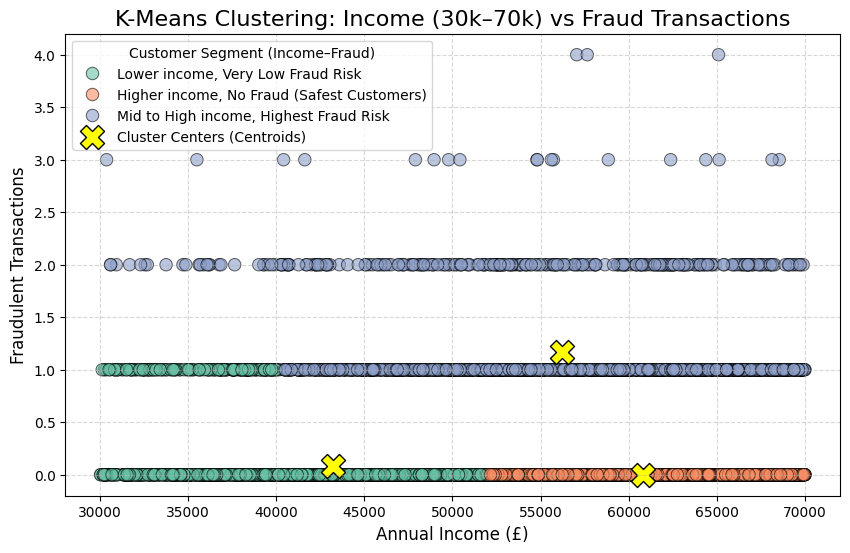

--- Average Values per Income–Fraud Segment (30k–70k income only) ---
                                            Annual_Income  Fraud_Transactions
Income_Fraud_Segment                                                         
Higher income, No Fraud (Safest Customers)   60835.366964            0.000000
Lower income, Very Low Fraud Risk            43280.594647            0.079319
Mid to High income, Highest Fraud Risk       56198.336161            1.172853


In [13]:
# === K-MEANS: Income (30k–70k) vs Fraud_Transactions ===

# 1. Filter to only customers with income between 30k and 70k
income_min, income_max = 30000, 70000

df_income = df[(df['Annual_Income'] >= income_min) & 
               (df['Annual_Income'] <= income_max)].copy()

print(f"Number of customers in {income_min/1000:.0f}k–{income_max/1000:.0f}k range:",
      len(df_income))

# 2. Select features for clustering
income_features = ['Annual_Income', 'Fraud_Transactions']
X_income = df_income[income_features]

# 3. Scale the data (very important for K-Means)
income_scaler = StandardScaler()
X_income_scaled = income_scaler.fit_transform(X_income)

# 4. Build the K-Means model (again, 3 clusters)
kmeans_income = KMeans(n_clusters=3, random_state=42, n_init=10)
df_income['Income_Fraud_Cluster'] = kmeans_income.fit_predict(X_income_scaled)

# (Optional) Give simple names to the clusters
income_segment_names = {
    0: 'Lower income, Very Low Fraud Risk',
    1: 'Higher income, No Fraud (Safest Customers)',
    2: 'Mid to High income, Highest Fraud Risk'
}
df_income['Income_Fraud_Segment'] = df_income['Income_Fraud_Cluster'].map(income_segment_names)

# 5. Get unscaled cluster centers for plotting
income_centers_unscaled = income_scaler.inverse_transform(kmeans_income.cluster_centers_)

# 6. Scatter "blob" plot: Income vs Fraud
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_income,
    x='Annual_Income',
    y='Fraud_Transactions',
    hue='Income_Fraud_Segment',   # or 'Income_Fraud_Cluster' if you prefer numbers
    palette='Set2',
    s=80,
    alpha=0.6,
    edgecolor='black'
)

# Plot the centroids
plt.scatter(
    income_centers_unscaled[:, 0],
    income_centers_unscaled[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolor='black',
    label='Cluster Centers (Centroids)'
)

plt.title('K-Means Clustering: Income (30k–70k) vs Fraud Transactions', fontsize=16)
plt.xlabel('Annual Income (£)', fontsize=12)
plt.ylabel('Fraudulent Transactions', fontsize=12)
plt.legend(title='Customer Segment (Income–Fraud)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 7. Averages per cluster – handy for your explanation / report
print("--- Average Values per Income–Fraud Segment (30k–70k income only) ---")
print(df_income.groupby('Income_Fraud_Segment')[income_features].mean())

Income vs. Fraud

Within the mid-income band, the highest fraud risk segment is not the lowest earners but the mid-to-high income group (avg £56,198, 1.17 avg fraud transactions), while the highest earners (avg £60,835) show zero average fraud. 

This counterintuitive finding suggests income alone is not a reliable fraud proxy in this segment, and behavioural signals should take precedence over income-based screening. 

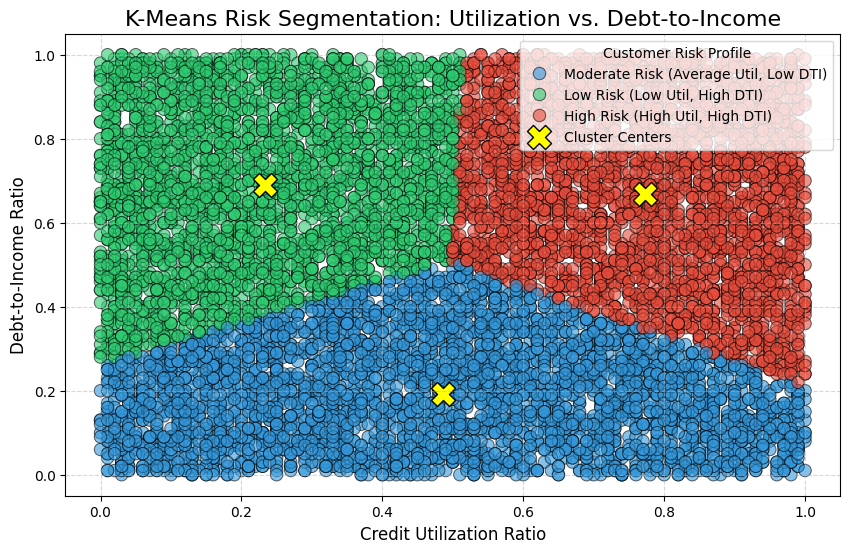

--- Average Financial Behaviors & Default Risk by Cluster ---
   Cluster  Credit_Utilization_Ratio  Debt_To_Income_Ratio  Defaulted
0        0                  0.486238              0.191590   0.343116
1        1                  0.233351              0.689314   0.215680
2        2                  0.773342              0.669292   0.472624


In [17]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Select behavioral features for clustering
features = ['Credit_Utilization_Ratio', 'Debt_To_Income_Ratio']
X = df[features]

# 4. Scale the data (Mandatory for K-Means distance calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Build the K-Means Model
# We set n_clusters=3 to create 3 distinct "Risk Profiles"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Let's calculate the ACTUAL Default Rate for each of the AI's clusters
# This is where the business magic happens!
cluster_stats = df.groupby('Cluster').agg({
    'Credit_Utilization_Ratio': 'mean',
    'Debt_To_Income_Ratio': 'mean',
    'Defaulted': 'mean' # The average default rate for people in this group!
}).reset_index()

# Map the clusters to meaningful business names based on the stats
# (Note: Cluster 2 in your dataset corresponds to high util & high DTI)
segment_names = {
    0: 'Moderate Risk (Average Util, Low DTI)', 
    1: 'Low Risk (Low Util, High DTI)', 
    2: 'High Risk (High Util, High DTI)'
}
df['Risk_Profile'] = df['Cluster'].map(segment_names)

# 7. VISUALIZATION: The Scatter Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Credit_Utilization_Ratio',
    y='Debt_To_Income_Ratio',
    hue='Risk_Profile',
    palette=['#3498db', '#2ecc71', '#e74c3c'], # Blue, Green, Red (Danger)
    s=80,
    alpha=0.6,
    edgecolor='black'
)

# Add the Centroids (Yellow X marks)
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_unscaled[:, 0], 
    centers_unscaled[:, 1], 
    c='yellow', 
    s=300, 
    marker='X', 
    edgecolor='black', 
    label='Cluster Centers'
)

plt.title('K-Means Risk Segmentation: Utilization vs. Debt-to-Income', fontsize=16)
plt.xlabel('Credit Utilization Ratio', fontsize=12)
plt.ylabel('Debt-to-Income Ratio', fontsize=12)
plt.legend(title='Customer Risk Profile')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 8. Print the exact stats so you can copy them into your report!
print("--- Average Financial Behaviors & Default Risk by Cluster ---")
print(cluster_stats)

Credit Utilization vs. Debt-to-Income Ratio 

This is the most actionable segmentation. Three risk profiles emerge with significantly different default rates: 

In [10]:

data = {
    'Segment': ['Low Risk', 'Moderate Risk', 'High Risk'],
    'Avg Utilisation': ['23.3%', '48.6%', '77.3%'],
    'Avg DTI': [0.69, 0.19, 0.67],
    'Default Rate': ['21.6%', '34.3%', '47.3%']
}

df_summary = pd.DataFrame(data)
df_summary.style.set_caption("Credit Utilisation vs DTI - Customer Risk Segments")

,Segment,Avg Utilisation,Avg DTI,Default Rate
0,Low Risk,23.3%,0.690000,21.6%
1,Moderate Risk,48.6%,0.190000,34.3%
2,High Risk,77.3%,0.670000,47.3%


The High Risk segment defaults at more than double the rate of the Low Risk group. Notably, the Low Risk segment carries high DTI but low utilisation - these customers are indebted but managing their credit responsibly. 

The High Risk segment combines both high DTI and high utilisation, a combination that proves far more predictive than either metric in isolation. At 3,178 customers (31.8% of the dataset), this segment represents a disproportionate share of the bank's total default exposure and should be the primary focus of proactive credit risk intervention. 

## 4 Prediction Modelling

In [18]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable


### Fraud Related Prediction Modelling

--- RANDOM FOREST MODEL EVALUATION ---
Overall Accuracy: 0.58

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.68      1439
           1       0.33      0.49      0.40       561

    accuracy                           0.58      2000
   macro avg       0.55      0.55      0.54      2000
weighted avg       0.64      0.58      0.60      2000



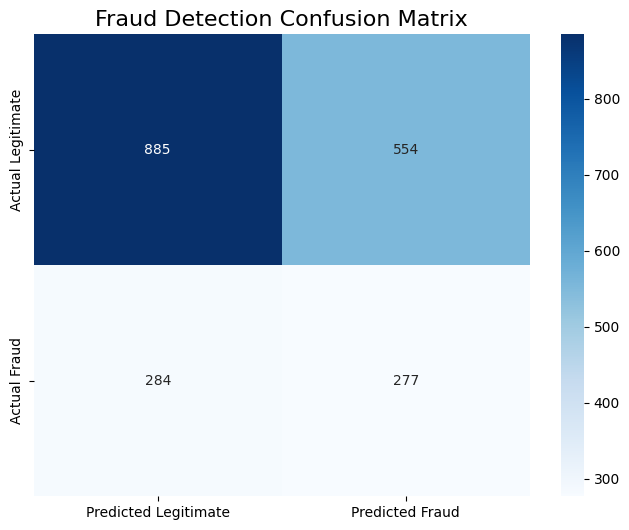

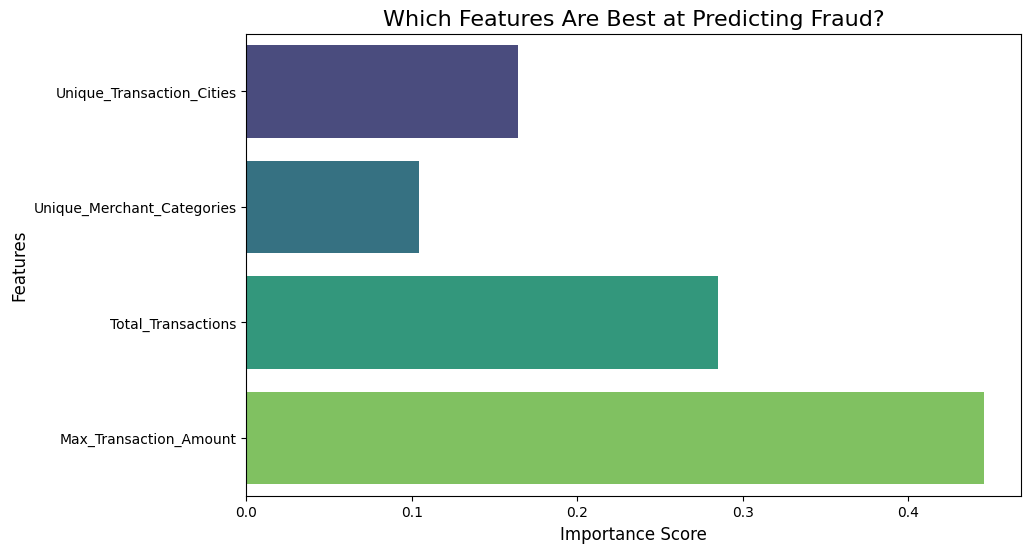

In [19]:
# 1. Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load the data (assuming it's already loaded, but safe to include)
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create our Target Variable (1 = Fraudulent, 0 = Legitimate)
df['Is_Fraud'] = (df['Fraud_Transactions'] > 0).astype(int)

# 4. Select the Predictive Features
features = [
    'Unique_Transaction_Cities', 
    'Unique_Merchant_Categories', 
    'Total_Transactions', 
    'Max_Transaction_Amount'
]

X = df[features]
y = df['Is_Fraud']

# 5. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Build the Random Forest Model 
# n_estimators=100 means it builds 100 different decision trees and averages their guesses
# class_weight='balanced' helps it pay extra attention to the rare fraud cases
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = rf_model.predict(X_test)

# 8. PRINT THE TEXT EVALUATION (For Stage 4 of your report)
print("--- RANDOM FOREST MODEL EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'], 
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title('Fraud Detection Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
sns.barplot(x=importances, y=features, palette='viridis', hue=features, legend=False)
plt.title('Which Features Are Best at Predicting Fraud?', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

[LightGBM] [Info] Number of positive: 2267, number of negative: 5733
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 310
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

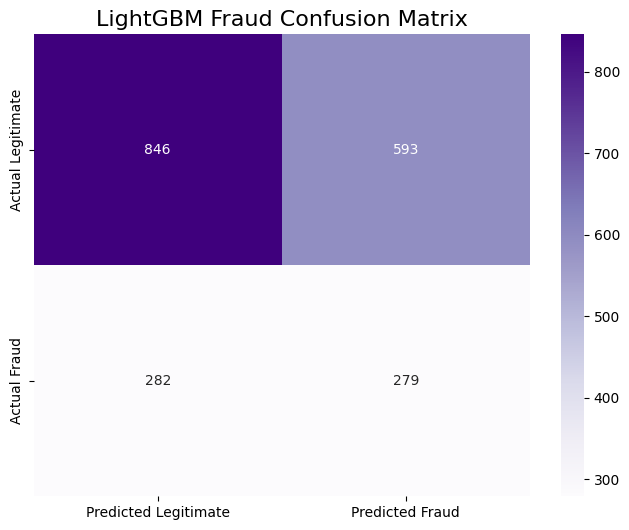

<Figure size 1000x600 with 0 Axes>

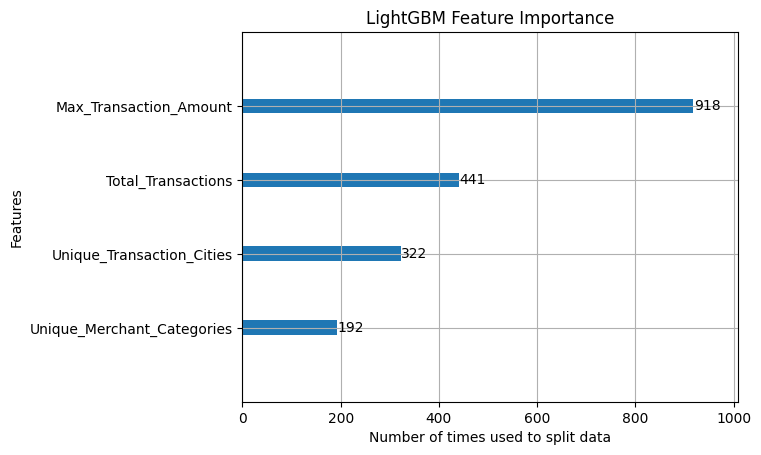

In [21]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb

# 2. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create the Binary Target Variable (1 = Fraud, 0 = Legitimate)
df['Is_Fraud'] = (df['Fraud_Transactions'] > 0).astype(int)

# 4. Select the Predictive Features
features = [
    'Unique_Transaction_Cities', 
    'Unique_Merchant_Categories', 
    'Total_Transactions', 
    'Max_Transaction_Amount'
]

X = df[features]
y = df['Is_Fraud']

# 5. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Build and Train the LightGBM Model
# class_weight='balanced' ensures it pays attention to the minority fraud cases
lgb_model = lgb.LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)

lgb_model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = lgb_model.predict(X_test)

# 8. TEXT EVALUATION
print("--- LIGHTGBM FRAUD PREDICTION EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', # Using Purples for a fresh look!
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'], 
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title('LightGBM Fraud Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: LightGBM Built-in Feature Importance
plt.figure(figsize=(10, 6))
# LightGBM has its own plotting function which looks very professional!
lgb.plot_importance(lgb_model, importance_type='split', max_num_features=10, 
                    title='LightGBM Feature Importance', xlabel='Number of times used to split data')
plt.show()

### Default Related Prediction Modelling

--- RANDOM FOREST DEFAULT PREDICTION EVALUATION ---
Overall Accuracy: 0.62

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.58      0.67      1320
           1       0.46      0.69      0.55       680

    accuracy                           0.62      2000
   macro avg       0.62      0.64      0.61      2000
weighted avg       0.67      0.62      0.63      2000



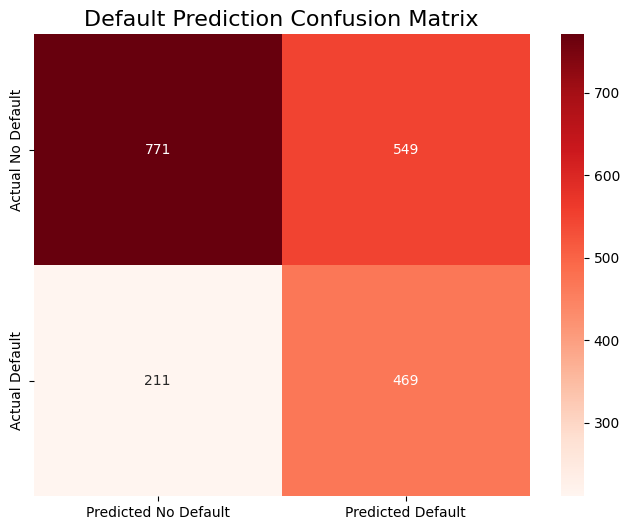

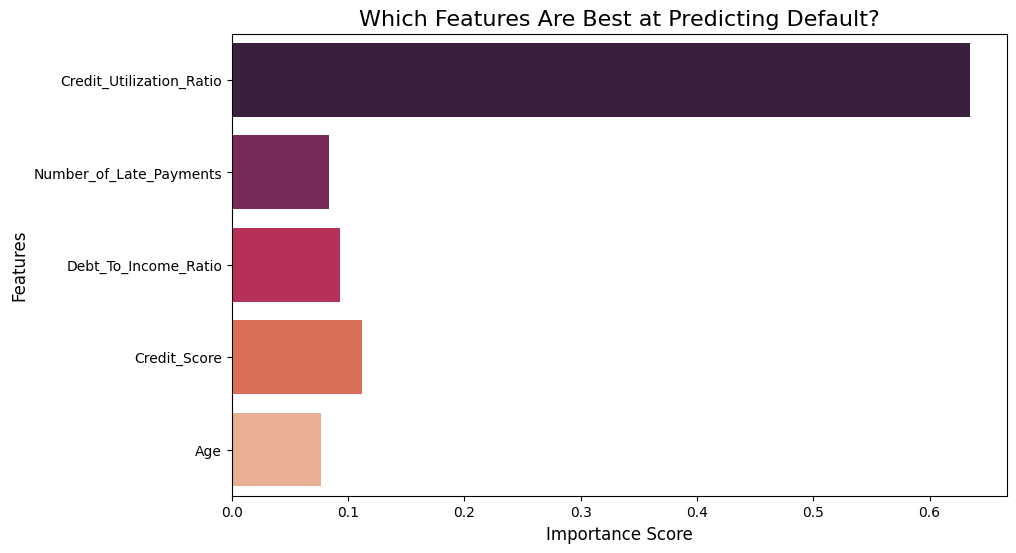

In [20]:
# 1. Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load the data
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create our Target Variable 
# We don't need to do any math here, because 'Defaulted' is already a 0 or 1 in your dataset!
y = df['Defaulted']

# 4. Select the Predictive Features
# We swapped these out for the features that actually relate to credit risk!
features = [
    'Credit_Utilization_Ratio', 
    'Number_of_Late_Payments', 
    'Debt_To_Income_Ratio', 
    'Credit_Score',
    'Age'
]

X = df[features]

# 5. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Build the Random Forest Model 
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = rf_model.predict(X_test)

# 8. PRINT THE TEXT EVALUATION (For Stage 4 of your report)
print("--- RANDOM FOREST DEFAULT PREDICTION EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', # Changed to Reds to match the risk theme
            xticklabels=['Predicted No Default', 'Predicted Default'], 
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Default Prediction Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
ax = sns.barplot(x=importances, y=features, palette='rocket', hue=features)

# Clean up the legend if one accidentally appears
if ax.get_legend():
    ax.get_legend().remove()

plt.title('Which Features Are Best at Predicting Default?', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

--- LOGISTIC REGRESSION: DEFAULT PREDICTION ---
Overall Accuracy: 0.63

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.68      1320
           1       0.46      0.65      0.54       680

    accuracy                           0.63      2000
   macro avg       0.62      0.63      0.61      2000
weighted avg       0.67      0.63      0.64      2000



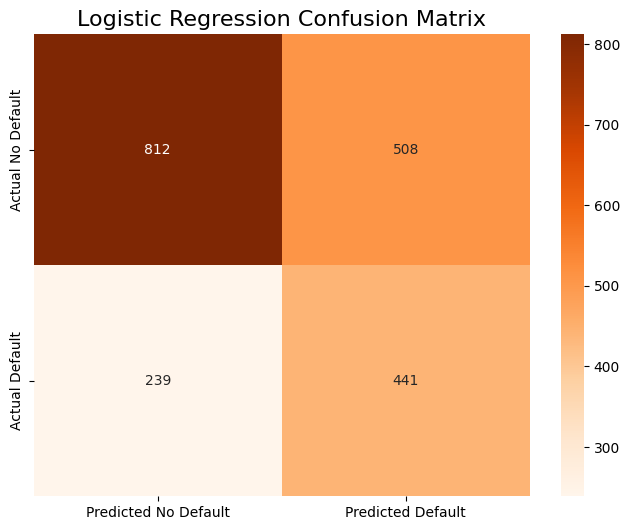

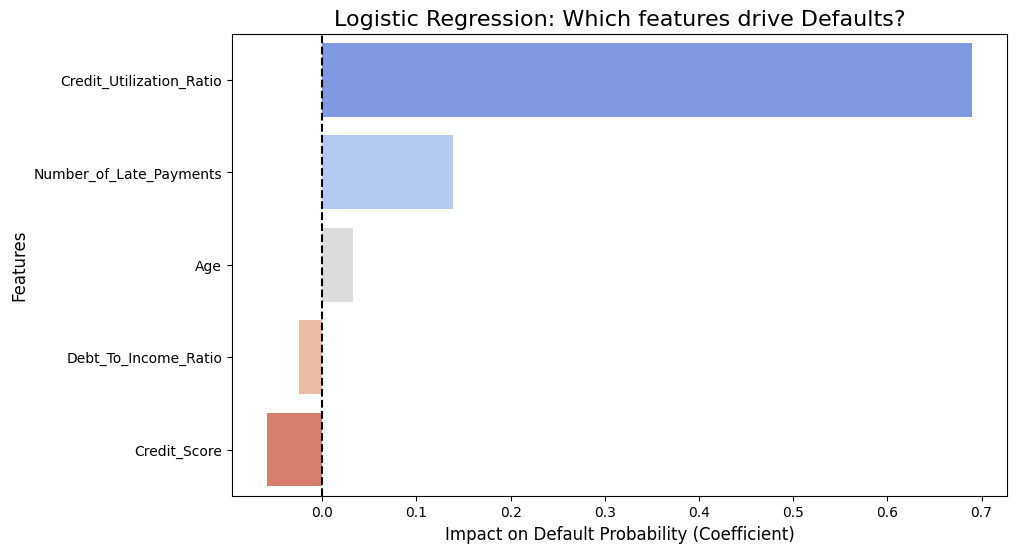

In [22]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load the data
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create Target Variable and Features
y = df['Defaulted']

features = [
    'Credit_Utilization_Ratio', 
    'Number_of_Late_Payments', 
    'Debt_To_Income_Ratio', 
    'Credit_Score',
    'Age'
]

X = df[features]

# 4. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. SCALE THE DATA (Crucial for Logistic Regression!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # We only transform the test set so the model can't "cheat" and see it early

# 6. Build the Logistic Regression Model
# class_weight='balanced' ensures it pays equal attention to the defaults
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

# 7. Make Predictions
y_pred_log = log_model.predict(X_test_scaled)

# 8. TEXT EVALUATION
print("--- LOGISTIC REGRESSION: DEFAULT PREDICTION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_log):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_log))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted No Default', 'Predicted Default'], 
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Logistic Regression Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: Feature Importance (Coefficients)
# Logistic Regression doesn't have "feature importances", it has "coefficients"
coefficients = pd.DataFrame({
    'Feature': features, 
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Logistic Regression: Which features drive Defaults?', fontsize=16)
plt.xlabel('Impact on Default Probability (Coefficient)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Adds a line at zero
plt.show()

## 7 Association Rule Mining 

In [23]:
# 1. Import Libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 2. Load Data
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. DISCRETIZATION: Convert numbers into True/False "Market Basket" items
basket = pd.DataFrame()

# We define what "High" means for each category to create our True/False columns
basket['High_Utilization'] = df['Credit_Utilization_Ratio'] >= 0.70
basket['Has_Late_Payments'] = df['Number_of_Late_Payments'] >= 1
basket['High_Debt_to_Income'] = df['Debt_To_Income_Ratio'] >= 0.50
basket['Low_Credit_Score'] = df['Credit_Score'] <= 650
basket['Has_Defaulted'] = df['Defaulted'] == 1

# Ensure everything is strictly a Boolean (True/False) format for the algorithm
basket = basket.astype(bool)

# 4. RUN APRIORI ALGORITHM
# min_support=0.1 means a combination must appear in at least 10% of customers to be considered a "rule"
frequent_itemsets = apriori(basket, min_support=0.1, use_colnames=True)

# 5. GENERATE THE RULES
# We use 'lift' to measure how strongly the items are connected. 
# A lift > 1 means the items appear together more often than random chance.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# 6. FILTER THE RULES FOR OUR BUSINESS PROBLEM
# We only care about rules where the result (the "consequent") is 'Has_Defaulted'
default_rules = rules[rules['consequents'] == frozenset({'Has_Defaulted'})]

# 7. Sort the rules by "Confidence" (how often the rule is right)
default_rules = default_rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

# 8. Print the top 5 most powerful risk rules!
print("--- Top Association Rules for Predicting Defaults ---")
for index, row in default_rules.head(5).iterrows():
    # Formatting it to read like plain English
    antecedents = list(row['antecedents'])
    confidence = row['confidence'] * 100
    lift = row['lift']
    print(f"IF a customer has {antecedents}, THEN they have a {confidence:.1f}% chance of Defaulting. (Lift: {lift:.2f})")

--- Top Association Rules for Predicting Defaults ---
IF a customer has ['High_Utilization'], THEN they have a 52.0% chance of Defaulting. (Lift: 1.51)
IF a customer has ['High_Utilization', 'Has_Late_Payments'], THEN they have a 51.6% chance of Defaulting. (Lift: 1.50)
